In [7]:
import numpy as np
from sklearn.preprocessing import LabelEncoder

# Caminho para os dados processados
PROJECT = '/content/drive/MyDrive/gtzan_projeto'
TAB = f'{PROJECT}/data/processed/tabular'


X_train = np.load(f'{TAB}/X_train.npy')
X_val = np.load(f'{TAB}/X_val.npy')
X_test = np.load(f'{TAB}/X_test.npy')

y_train = np.load(f'{TAB}/y_train.npy', allow_pickle=True)
y_val = np.load(f'{TAB}/y_val.npy', allow_pickle=True)
y_test = np.load(f'{TAB}/y_test.npy', allow_pickle=True)

# Transformando os rótulos de texto em números (0 a 9)
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc = le.transform(y_val)
y_test_enc = le.transform(y_test)

print('Classes:', le.classes_)

Classes: ['blues' 'classical' 'country' 'disco' 'hiphop' 'jazz' 'metal' 'pop'
 'reggae' 'rock']


In [8]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# Configurando o modelo MLP
mlp = MLPClassifier(
    hidden_layer_sizes=(256, 128, 64),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=300,
    early_stopping=True,
    n_iter_no_change=20,
    random_state=42,
    verbose=True
)

# Treinando o modelo
print("Iniciando o treinamento do MLP...")
mlp.fit(X_train, y_train_enc)

# Avaliando na validação
print('Acurácia na validação:', accuracy_score(y_val_enc, mlp.predict(X_val)))

Iniciando o treinamento do MLP...
Iteration 1, loss = 2.18540006
Validation score: 0.342857
Iteration 2, loss = 1.84067169
Validation score: 0.385714
Iteration 3, loss = 1.64403403
Validation score: 0.357143
Iteration 4, loss = 1.46567365
Validation score: 0.471429
Iteration 5, loss = 1.31745860
Validation score: 0.571429
Iteration 6, loss = 1.17969679
Validation score: 0.571429
Iteration 7, loss = 1.07234883
Validation score: 0.571429
Iteration 8, loss = 0.98490411
Validation score: 0.585714
Iteration 9, loss = 0.89156662
Validation score: 0.628571
Iteration 10, loss = 0.82901135
Validation score: 0.642857
Iteration 11, loss = 0.76173176
Validation score: 0.614286
Iteration 12, loss = 0.69744029
Validation score: 0.657143
Iteration 13, loss = 0.64261619
Validation score: 0.671429
Iteration 14, loss = 0.59993769
Validation score: 0.671429
Iteration 15, loss = 0.55180236
Validation score: 0.685714
Iteration 16, loss = 0.52321181
Validation score: 0.700000
Iteration 17, loss = 0.48947254

In [9]:
from sklearn.model_selection import RandomizedSearchCV

# Definindo o espaço de busca dos hiperparâmetros
param_dist = {
    'hidden_layer_sizes': [(128,), (256, 128), (256, 128, 64), (512, 256, 128)],
    'activation': ['relu', 'tanh'],
    'learning_rate_init': [0.01, 0.001, 0.0001],
    'alpha': [0.0001, 0.001, 0.01],
}

# Configurando o RandomizedSearchCV
search = RandomizedSearchCV(
    MLPClassifier(max_iter=300, early_stopping=True, random_state=42),
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Iniciando a busca
print("Iniciando a busca de hiperparâmetros...")
search.fit(X_train, y_train_enc)

# Exibindo o grande vencedor
print('Melhor configuração:', search.best_params_)

Iniciando a busca de hiperparâmetros...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Melhor configuração: {'learning_rate_init': 0.01, 'hidden_layer_sizes': (128,), 'alpha': 0.0001, 'activation': 'relu'}


              precision    recall  f1-score   support

       blues       0.76      0.87      0.81        15
   classical       1.00      1.00      1.00        15
     country       0.93      0.87      0.90        15
       disco       0.62      0.67      0.65        15
      hiphop       0.62      0.67      0.65        15
        jazz       0.93      0.87      0.90        15
       metal       0.91      0.67      0.77        15
         pop       0.80      0.80      0.80        15
      reggae       0.61      0.73      0.67        15
        rock       0.64      0.60      0.62        15

    accuracy                           0.77       150
   macro avg       0.78      0.77      0.78       150
weighted avg       0.78      0.77      0.78       150



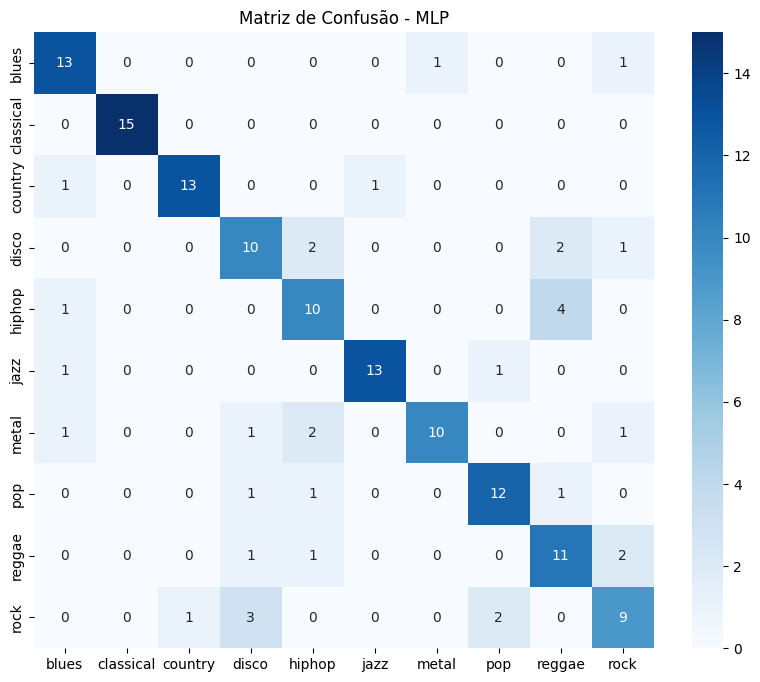

In [11]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Resgatando o modelo vencedor
best_mlp = search.best_estimator_

# Prevendo os dados de validação
y_pred_val = best_mlp.predict(X_val)

# Relatório de classificação detalhado
print(classification_report(y_val_enc, y_pred_val, target_names=le.classes_))

# Gerando e plotando a matriz de confusão
cm = confusion_matrix(y_val_enc, y_pred_val)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.title('Matriz de Confusão - MLP')

# Salvando a imagem na pasta resultados do Drive compartilhado
plt.savefig(f'{PROJECT}/resultados/confusion_matrix_mlp.png', dpi=150)
plt.show()

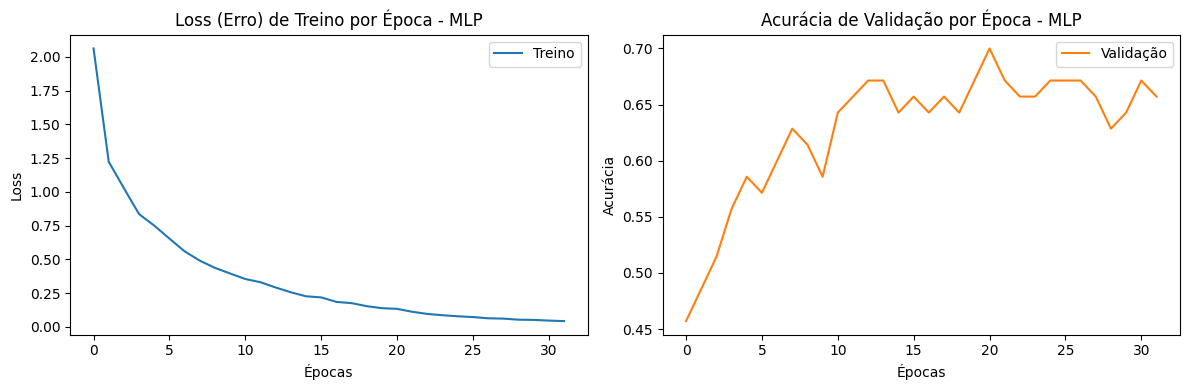

Gráfico salvo com sucesso no Drive: mlp_training_curves.png


In [12]:
import matplotlib.pyplot as plt

# Criando a figura com 2 gráficos lado a lado
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico 1: Erro (Loss) no Treinamento
axes[0].plot(best_mlp.loss_curve_, label='Treino', color='tab:blue')
axes[0].set_title('Loss (Erro) de Treino por Época - MLP')
axes[0].set_xlabel('Épocas')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Gráfico 2: Acurácia de Validação
# (O early_stopping=True faz o scikit-learn guardar esses dados automaticamente)
if hasattr(best_mlp, 'validation_scores_'):
    axes[1].plot(best_mlp.validation_scores_, label='Validação', color='tab:orange')
    axes[1].set_title('Acurácia de Validação por Época - MLP')
    axes[1].set_xlabel('Épocas')
    axes[1].set_ylabel('Acurácia')
    axes[1].legend()

plt.tight_layout()

# Salvando a imagem na pasta compartilhada para o Overleaf ler
caminho_imagem = f'{PROJECT}/resultados/mlp_training_curves.png'
plt.savefig(caminho_imagem, dpi=150)
plt.show()

print(f"Gráfico salvo com sucesso no Drive: mlp_training_curves.png")

In [ ]:
import joblib

# Teste final com os dados isolados
y_pred_test = best_mlp.predict(X_test)
acc_test = accuracy_score(y_test_enc, y_pred_test)

print(f'Acurácia FINAL no teste: {acc_test:.4f}')

# Salvando o modelo treinado (.pkl)
joblib.dump(best_mlp, f'{PROJECT}/modelos/mlp_final.pkl')

# Salvando as predições para o notebook comparacao_final.ipynb (.npy)
np.save(f'{PROJECT}/resultados/y_pred_mlp_test.npy', y_pred_test)

print('Resultados do MLP salvos com sucesso no Drive!')